# Forecasting gold volatility with GARCH(1,1)

Notebook 03 fit a GARCH(1,1) model to gold's history and looked at how well it explained days we already have data for (in-sample fit) - that's not a forecast, just a description of the past.

This notebook does the actual forecasting: using the fitted model to project volatility forward into days beyond the data, where there's no real return to compute epsilon_t from.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

## Load data and refit the model

Each notebook runs independently (its own kernel), so we repeat the same load + fit steps from notebook 03 rather than depending on that notebook having been run first.

In [2]:
gold = pd.read_csv("../data/gold_futures.csv", skiprows=[1, 2], index_col=0, parse_dates=True)
gold.index.name = "Date"

returns = gold["Close"].pct_change().dropna() * 100

model = arch_model(returns, mean="Constant", vol="Garch", p=1, q=1, dist="normal")
result = model.fit(disp="off")
result.params

mu          0.026023
omega       0.019221
alpha[1]    0.052513
beta[1]     0.931333
Name: params, dtype: float64

## Forecast volatility forward

`result.forecast(horizon=10)` projects 10 trading days beyond the last day in the dataset. Recall how this actually works day by day, from our earlier walkthrough:

- Day 1 of the forecast (tomorrow) uses the *real* epsilon and sigma from the very last day in our data - genuinely informed by what actually just happened.
- Every day after that has no real epsilon to use (it hasn't happened yet), so the model substitutes the *expected* value of epsilon-squared, which works out to just sigma-squared itself. So the formula for those steps simplifies to `sigma_(t+1)^2 = omega + (alpha + beta) * sigma_t^2` - repeatedly applying this pulls the forecast toward the long-run variance the further out it goes.

The `.variance` property holds the forecast: one row (the last date in our data), with one column per day of the horizon.

In [3]:
forecast = result.forecast(horizon=10, reindex=False)

forecast_variance = forecast.variance.iloc[0]
forecast_volatility = np.sqrt(forecast_variance)
forecast_volatility.index = [f"Day +{i+1}" for i in range(len(forecast_volatility))]
forecast_volatility

Day +1     1.576039
Day +2     1.569394
Day +3     1.562828
Day +4     1.556341
Day +5     1.549933
Day +6     1.543602
Day +7     1.537348
Day +8     1.531170
Day +9     1.525067
Day +10    1.519039
Name: 2026-08-05 00:00:00, dtype: float64

## Compare to the long-run variance

`omega / (1 - alpha - beta)` is the resting level the model always settles toward. Plotting the forecast against this line should show the forecast curve bending toward it as the horizon extends - exactly the "pulled toward the long-run average" behavior described above.

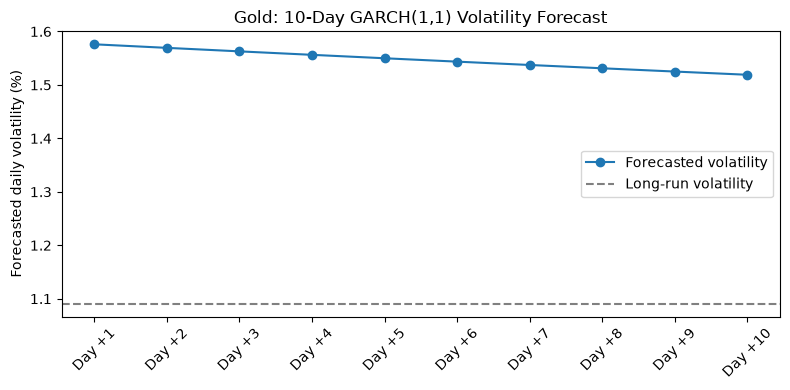

Long-run volatility: 1.0908%


In [4]:
omega = result.params["omega"]
alpha = result.params["alpha[1]"]
beta = result.params["beta[1]"]
long_run_volatility = np.sqrt(omega / (1 - alpha - beta))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(forecast_volatility.values, marker="o", label="Forecasted volatility")
ax.axhline(long_run_volatility, color="gray", linestyle="--", label="Long-run volatility")
ax.set_xticks(range(len(forecast_volatility)))
ax.set_xticklabels(forecast_volatility.index, rotation=45)
ax.set_ylabel("Forecasted daily volatility (%)")
ax.set_title("Gold: 10-Day GARCH(1,1) Volatility Forecast")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Long-run volatility: {long_run_volatility:.4f}%")